# RiMEA 12c: Influence of Congestion

This notebook demonstrates the three-room bottleneck scenario behind RiMEA Test 12c. The setup has two identical 1 m bottlenecks in series, but the crowd starts only in room 1. The expectation is that we see strong congestion upstream of bottleneck 1, while room 2 and bottleneck 2 remain less congested.

To show that behavior, the notebook:

- plots the geometry, trajectories, and both measurement lines
- compares the cumulative crossings at bottleneck 1 and bottleneck 2
- computes an averaged Gaussian speed profile over the whole geometry

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pedpy

from core.scenario import load_scenario, run_scenario

In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "xtick.color": "#1d1d1d",
        "ytick.color": "#1d1d1d",
        "font.size": 11,
    }
)

SCENARIO_DIR = Path("scenarios") / "rimea-12c-congestion-influence"
BOTTLENECK_LINES = [
    pedpy.MeasurementLine([(10.0, 4.5), (10.0, 5.5)]),
    pedpy.MeasurementLine([(20.2, 4.5), (20.2, 5.5)]),
]
GRID_SIZE = 0.25
FRAME_STEP = 10


## Load and Run the Scenario

In [3]:
%%capture
scenario = load_scenario(str(SCENARIO_DIR))
print(scenario.summary())

result = run_scenario(scenario, seed=42)
traj = pedpy.TrajectoryData(
    result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(),
    frame_rate=result.frame_rate,
)
walkable_area = pedpy.WalkableArea(scenario.walkable_polygon)
result.metrics

## Plot Geometry, Trajectories, and Measurement Lines

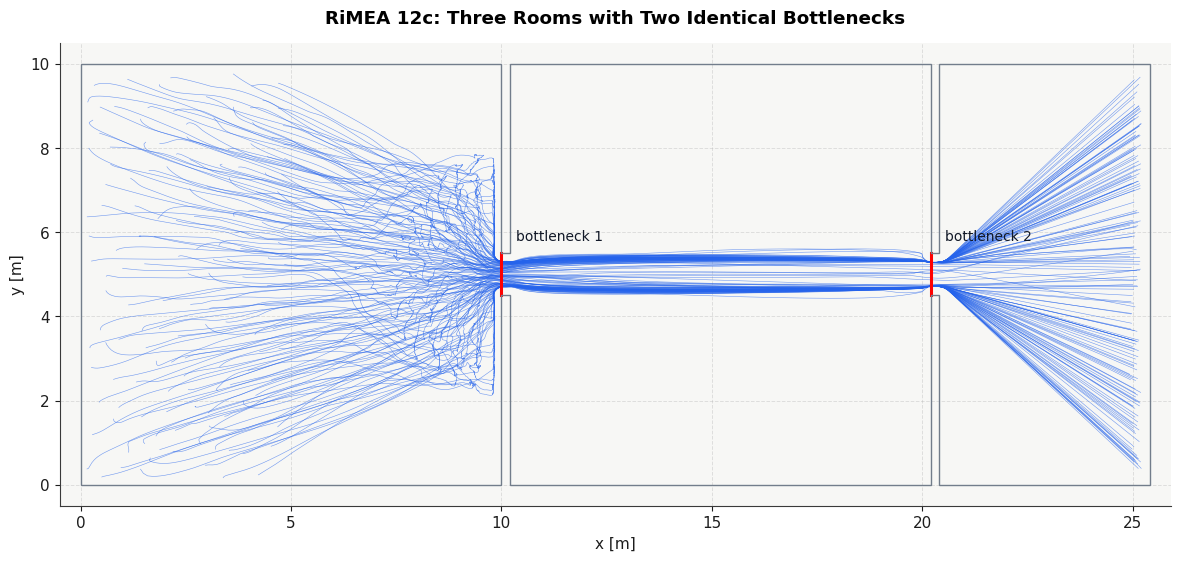

In [4]:
fig, ax = plt.subplots(figsize=(14, 5.5), constrained_layout=True)
pedpy.plot_measurement_setup(
    traj=traj,
    walkable_area=walkable_area,
    measurement_lines=BOTTLENECK_LINES,
    axes=ax,
    traj_alpha=0.65,
    traj_width=0.4,
    ml_width=2.2,
    ml_alpha=0.25,
    traj_color="#2563EB",
    ml_color="red",
).set_aspect("equal")
ax.text(10.35, 5.8, "bottleneck 1", fontsize=10, color="#111827")
ax.text(20.55, 5.8, "bottleneck 2", fontsize=10, color="#111827")
ax.set_title("RiMEA 12c: Three Rooms with Two Identical Bottlenecks", pad=14)
ax.set_xlim(-0.5, 25.9)
ax.set_ylim(-0.5, 10.5)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

## Compare Crossings at the Two Bottlenecks

If room 2 does not build up the same congestion as room 1, the second bottleneck should see a delayed but smoother stream of agents rather than a comparable upstream jam.

In [5]:
nt_1, crossing_1 = pedpy.compute_n_t(traj_data=traj, measurement_line=BOTTLENECK_LINES[0])
nt_2, crossing_2 = pedpy.compute_n_t(traj_data=traj, measurement_line=BOTTLENECK_LINES[1])

summary = {
    "bottleneck_1_last_crossing_s": round(float(crossing_1['frame'].max() / traj.frame_rate), 2),
    "bottleneck_2_last_crossing_s": round(float(crossing_2['frame'].max() / traj.frame_rate), 2),
    "bottleneck_1_crossings": int(len(crossing_1)),
    "bottleneck_2_crossings": int(len(crossing_2)),
}
summary

{'bottleneck_1_last_crossing_s': 95.2,
 'bottleneck_2_last_crossing_s': 106.0,
 'bottleneck_1_crossings': 150,
 'bottleneck_2_crossings': 150}

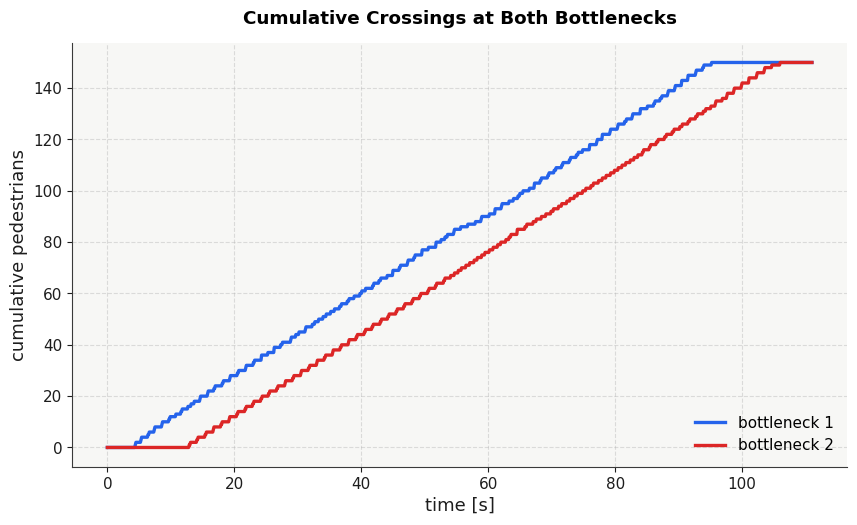

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
time_1 = nt_1['time']
time_2 = nt_2['time']

ax.plot(time_1, nt_1['cumulative_pedestrians'], color="#2563EB", linewidth=2.4, label="bottleneck 1")
ax.plot(time_2, nt_2['cumulative_pedestrians'], color="#DC2626", linewidth=2.4, label="bottleneck 2")
ax.set_title("Cumulative Crossings at Both Bottlenecks", pad=14)
ax.set_xlabel("time [s]", fontsize=13)
ax.set_ylabel("cumulative pedestrians", fontsize=13)
ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower right")
plt.show()

## Compute Density and Gaussian Speed Profiles

The density profile highlights where agents accumulate, while the Gaussian speed profile highlights where they slow down most strongly. In this setup, the strongest density increase and the lowest speeds should appear upstream of bottleneck 1, while room 2 should remain less congested on average.

In [7]:
density_profile = pedpy.compute_density_profile(
    data=traj.data,
    walkable_area=walkable_area,
    grid_size=GRID_SIZE,
    density_method=pedpy.DensityMethod.GAUSSIAN,
    gaussian_width=0.5,
)

speed_data = pedpy.compute_individual_speed(
    traj_data=traj,
    frame_step=FRAME_STEP,
    compute_velocity=True,
    speed_calculation=pedpy.SpeedCalculation.BORDER_SINGLE_SIDED,
)
profile_data = traj.data.merge(speed_data[['id', 'frame', 'speed']], on=['id', 'frame'], how='inner')

gauss_speed_profile = pedpy.compute_speed_profile(
    data=profile_data,
    walkable_area=walkable_area,
    grid_size=GRID_SIZE,
    gaussian_width=0.5,
    speed_method=pedpy.SpeedMethod.GAUSSIAN,
)

len(density_profile), len(gauss_speed_profile), np.asarray(gauss_speed_profile[0]).shape

/Users/chraibi/workspace/PedestrianDynamics/Web-Based-Jupedsim-issues/scripts/.venv/lib/python3.13/site-packages/pedpy/methods/profile_calculator.py:734: RuntimeWarning: invalid value encountered in divide
  normalized_weights = weights / np.sum(


(1111, 1111, (40, 102))

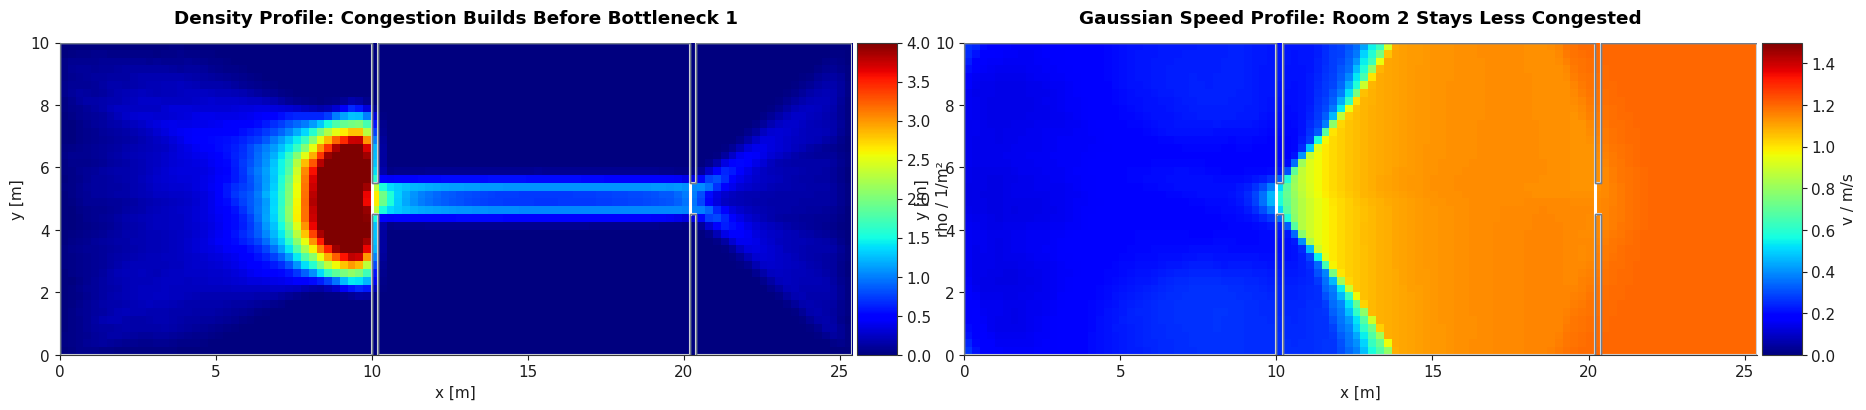

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.8), constrained_layout=True)
pedpy.plot_profiles(
    walkable_area=walkable_area,
    profiles=density_profile,
    axes=ax1,
    label='rho / 1/m²',
    vmin=0,
    vmax=4,
    title='Density',
)
pedpy.plot_measurement_setup(
    walkable_area=walkable_area,
    measurement_lines=BOTTLENECK_LINES,
    axes=ax1,
    ml_width=2.2,
    ml_alpha=0.45,
    ml_color='white',
)
ax1.set_title("Density Profile: Congestion Builds Before Bottleneck 1", pad=14)
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_xlim(0, 25.4)
ax1.set_ylim(0, 10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

pedpy.plot_profiles(
    walkable_area=walkable_area,
    profiles=gauss_speed_profile,
    axes=ax2,
    label='v / m/s',
    vmin=0,
    vmax=1.5,
    title='Gauss',
)
pedpy.plot_measurement_setup(
    walkable_area=walkable_area,
    measurement_lines=BOTTLENECK_LINES,
    axes=ax2,
    ml_width=2.2,
    ml_alpha=0.45,
    ml_color='white',
)
ax2.set_title("Gaussian Speed Profile: Room 2 Stays Less Congested", pad=14)
ax2.set_xlabel("x [m]")
ax2.set_ylabel("y [m]")
ax2.set_xlim(0, 25.4)
ax2.set_ylim(0, 10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
plt.show()

## Clean Up

In [9]:
result.cleanup()